# 02 — Baseline Multimodal (hasta 10 imágenes)

Fine-tuning de **Qwen2.5-VL-3B-Instruct** con LoRA para detección de datos de contacto en listings MeLi.

| Parámetro | Valor |
|-----------|-------|
| Modelo base | Qwen2.5-VL-3B-Instruct (FP16) |
| LoRA rank / alpha | r=8 / α=16 |
| GPU objetivo | A100 (40 GB) |
| Imágenes / listing | hasta 10 |
| Métrica principal | F2-score |

**Prerequisito:** haber corrido `01_build_splits.ipynb` para tener `train.csv` y `val.csv` en Drive.

**Estrategia de imágenes:**
- Drive (`DRIVE_IMGS_DIR`): descarga persistente, una sola vez
- Training directo desde Drive (sin copia local)

## 0 — Setup y dependencias

In [ ]:
!cd /content/meli-contact-detection && git pull

Already up to date.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Setup: monta Drive, clona/actualiza repo, instala deps base
exec(open('/content/drive/MyDrive/contact-detection/scripts/colab_setup.py').read())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Repo actualizado en /content/meli-contact-detection
✅ Dependencias instaladas

Setup completo:
  DRIVE_ROOT  = /content/drive/MyDrive/contact-detection
  POOLS_DIR   = /content/drive/MyDrive/contact-detection/data/pools
  SPLITS_DIR  = /content/drive/MyDrive/contact-detection/data/splits
  OUTPUTS_DIR = /content/drive/MyDrive/contact-detection/outputs
  REPO_DIR    = /content/meli-contact-detection



In [ ]:
# Instalar Unsloth (requiere restart del kernel la primera vez)
import subprocess
subprocess.run(['pip', 'install', '-q', 'unsloth'], check=True)
subprocess.run(['pip', 'install', '--upgrade', '-q', 'unsloth_zoo'], check=True)
print('✅ Unsloth instalado')

✅ Unsloth instalado


In [ ]:
import subprocess, sys, linecache, importlib

# ── Patch rl.py desde proceso limpio ─────────────────────────────────────────
patch_script = '''
import sys, pathlib, textwrap

old = 'sanitize_logprob = RL_REPLACEMENTS["sanitize_logprob"]'
new = textwrap.dedent("""
    def _sanitize_logprob_stub(logprobs, *args, **kwargs):
        return logprobs
    sanitize_logprob = RL_REPLACEMENTS.get("sanitize_logprob", _sanitize_logprob_stub)
""").strip()

for p in sys.path:
    rl = pathlib.Path(p) / "unsloth" / "models" / "rl.py"
    if rl.exists():
        code = rl.read_text()
        if old in code:
            rl.write_text(code.replace(old, new))
            for pyc in (rl.parent / "__pycache__").glob("rl.cpython*.pyc"):
                pyc.unlink()
            print(f"PATCHED: {rl}")
        else:
            print(f"YA OK:   {rl}")
'''
r = subprocess.run(['python3', '-c', patch_script], capture_output=True, text=True)
print(r.stdout or '(sin output)')
if r.stderr:
    print('stderr:', r.stderr[:200])

# ── Limpiar cachés ────────────────────────────────────────────────────────────
linecache.clearcache()
importlib.invalidate_caches()
for key in list(sys.modules.keys()):
    if 'unsloth' in key:
        del sys.modules[key]

# ── Unsloth PRIMERO ───────────────────────────────────────────────────────────
from unsloth import FastVisionModel

import os, gc, json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yaml
from pathlib import Path
from transformers import AutoProcessor, Trainer, TrainingArguments

REPO_DIR = '/content/meli-contact-detection'
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)

from src.data.dataset      import csv_to_dataset
from src.data.collator     import build_multimodal_collator, smoke_test
from src.inference.predict import predict_one
from src.engine.decision   import decide

os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
gc.collect(); torch.cuda.empty_cache()

print('✅ imports OK')
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')
print('VRAM total:', f"{torch.cuda.get_device_properties(0).total_memory/1024**3:.1f} GB")

YA OK:   /usr/local/lib/python3.12/dist-packages/unsloth/models/rl.py

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


✅ imports OK
GPU: Tesla T4
VRAM total: 14.6 GB


## 1 — Configuración

In [ ]:
DRIVE_ROOT  = '/content/drive/MyDrive/contact-detection'
SPLITS_DIR  = f'{DRIVE_ROOT}/data/splits'
OUTPUTS_DIR = f'{DRIVE_ROOT}/outputs'
CONFIG_PATH = f'{REPO_DIR}/configs/qwen25_3b.yaml'

# Imágenes: Drive (persistente) → local (rápido para training)
DRIVE_IMGS_DIR = f'{DRIVE_ROOT}/data/images'  # se descarga acá una sola vez
LOCAL_IMGS_DIR = '/content/images'             # se copia al inicio de cada sesión

with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

MODEL_NAME   = cfg['model']['name']
LOAD_4BIT    = cfg['model']['load_in_4bit']
MAX_IMAGES   = cfg['data']['max_images']        # 10
IMG_MAX_SIDE = cfg['data']['img_max_side']       # 512
PROMPT_CHARS = cfg['data']['prompt_max_chars']   # 2500
SEED         = cfg['data']['seed']               # 42

# Ajustá según el tiempo disponible:
#   N_TRAIN=5000  → ~15 min descarga + ~30 min training (T4)
#   N_TRAIN=None  → dataset completo (65k), solo si imágenes ya están en Drive
N_TRAIN = 5000
N_VAL   = 1000

print(f'Modelo  : {MODEL_NAME}')
print(f'LoRA    : r={cfg["peft"]["r"]} / alpha={cfg["peft"]["lora_alpha"]}')
print(f'Épocas  : {cfg["training"]["num_train_epochs"]}')
print(f'N_TRAIN : {N_TRAIN}  |  N_VAL : {N_VAL}')
print(f'Imgs Drive : {DRIVE_IMGS_DIR}')
print(f'Imgs local : {LOCAL_IMGS_DIR}')

## 2 — Dataset

In [ ]:
import shutil
from pathlib import Path

# Guard: avisar si N_TRAIN=None sin imágenes en Drive
if N_TRAIN is None:
    n_drive = sum(1 for _ in Path(DRIVE_IMGS_DIR, 'train').rglob('*.jpg')) if Path(DRIVE_IMGS_DIR, 'train').exists() else 0
    print(f'Imágenes en Drive/train: {n_drive:,}')
    if n_drive < 50_000:
        print(f'⚠️  Solo {n_drive:,} imgs en Drive. Primera descarga puede tardar horas.')
        print('   Considerá N_TRAIN=5000 para la primera sesión.')

# 8 workers: suficiente paralelismo sin saturar el FUSE mount de Drive
N_WORKERS = 8

print('Construyendo train dataset (descarga paralela a Drive si faltan imágenes)...')
ds_train = csv_to_dataset(
    csv_path            = f'{SPLITS_DIR}/train.csv',
    img_dir             = f'{DRIVE_IMGS_DIR}/train',
    max_images          = MAX_IMAGES,
    img_max_side        = IMG_MAX_SIDE,
    prompt_max_chars    = PROMPT_CHARS,
    seed                = SEED,
    limit               = N_TRAIN,
    n_download_workers  = N_WORKERS,
)

print('\nConstruyendo val dataset...')
ds_val = csv_to_dataset(
    csv_path            = f'{SPLITS_DIR}/val.csv',
    img_dir             = f'{DRIVE_IMGS_DIR}/val',
    max_images          = MAX_IMAGES,
    img_max_side        = IMG_MAX_SIDE,
    prompt_max_chars    = PROMPT_CHARS,
    seed                = SEED,
    limit               = N_VAL,
    n_download_workers  = N_WORKERS,
)

print(f'\nDataset en Drive: train={len(ds_train):,}  val={len(ds_val):,}')

In [ ]:
from datasets import DatasetDict
import os

# Verificar que todos los paths del dataset existen (deben estar en Drive)
missing = sum(1 for ex in ds_train for p in ex['image_path'] if not os.path.exists(p))
if missing:
    print(f'⚠️  {missing} paths faltantes en ds_train — revisá la descarga')
else:
    print(f'✅ Todos los paths de imágenes existen')

ds = DatasetDict({'train': ds_train, 'validation': ds_val})
print(f'✅ Dataset listo: train={len(ds["train"]):,}  val={len(ds["validation"]):,}')

In [ ]:
# Copia imágenes del dataset a disco local del A100 (evita Drive FUSE I/O durante training)
# ~2-5 min para 5000 ejemplos; sin esto la GPU queda ociosa esperando Drive reads.
import shutil, errno
from concurrent.futures import ThreadPoolExecutor

def _copy_one(src_path):
    rel = Path(src_path).relative_to(DRIVE_IMGS_DIR)
    dst = Path(LOCAL_IMGS_DIR) / rel
    if not dst.exists():
        dst.parent.mkdir(parents=True, exist_ok=True)
        try:
            shutil.copy2(src_path, dst)
        except OSError as e:
            if e.errno == errno.EIO:  # FUSE transient error → skip
                return None
            raise
    return str(dst)

# Recopilar paths únicos de ambos splits
all_paths = set()
for ex in ds_train:
    for p in ex['image_path']:
        all_paths.add(p)
for ex in ds_val:
    for p in ex['image_path']:
        all_paths.add(p)

print(f'Copiando {len(all_paths):,} imágenes a {LOCAL_IMGS_DIR} (16 workers)...')
with ThreadPoolExecutor(max_workers=16) as pool:
    list(pool.map(_copy_one, all_paths))
print('✅ Copia completa')

# Remapear paths en los datasets
def _remap(ex):
    ex['image_path'] = [
        str(Path(LOCAL_IMGS_DIR) / Path(p).relative_to(DRIVE_IMGS_DIR))
        for p in ex['image_path']
    ]
    return ex

from datasets import DatasetDict
ds_train = ds_train.map(_remap)
ds_val   = ds_val.map(_remap)
ds = DatasetDict({'train': ds_train, 'validation': ds_val})

# Verificar
missing = sum(1 for ex in ds_train for p in ex['image_path'] if not Path(p).exists())
print(f'Paths faltantes: {missing}  (debe ser 0)')
print(f'✅ Dataset listo (local): train={len(ds["train"]):,}  val={len(ds["validation"]):,}')

## 3 — Modelo + LoRA

In [ ]:
gc.collect()
torch.cuda.empty_cache()

# load_in_4bit=False → FP16, evita RecursionError de bitsandbytes con esta versión de Unsloth
# Modelo FP16 usa ~7-8 GB VRAM, cabe en T4 con gradient checkpointing
model, tokenizer = FastVisionModel.from_pretrained(
    MODEL_NAME,
    load_in_4bit = LOAD_4BIT,  # False en config (FP16)
    device_map   = 'auto',
)

model = FastVisionModel.get_peft_model(
    model,
    r            = cfg['peft']['r'],
    lora_alpha   = cfg['peft']['lora_alpha'],
    lora_dropout = cfg['peft']['lora_dropout'],
    bias         = cfg['peft']['bias'],
    target_modules = cfg['peft']['target_modules'],
)
# Gradient checkpointing estándar (sin bitsandbytes 4-bit, no da RecursionError)
model.gradient_checkpointing_enable(gradient_checkpointing_kwargs={"use_reentrant": False})

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ modelo cargado  (4bit={LOAD_4BIT})')
print(f'   Entrenables: {trainable_p:,} / {total_p:,} ({trainable_p/total_p:.3%})')
print(f'   VRAM: {torch.cuda.memory_allocated()/1024**3:.2f} GB alloc / {torch.cuda.memory_reserved()/1024**3:.2f} GB reserved')

## 4 — Collator (con label masking)

In [ ]:
processor = AutoProcessor.from_pretrained(MODEL_NAME)
collator  = build_multimodal_collator(processor)

# Verifica que label_frac << 1 (solo tokens de respuesta tienen loss)
smoke_test(collator, ds['train'], n=2)

## 5 — Entrenamiento

In [ ]:
t_cfg = cfg['training']

steps_per_epoch = len(ds['train']) // (
    t_cfg['per_device_train_batch_size'] * t_cfg['gradient_accumulation_steps']
)
total_steps     = steps_per_epoch * t_cfg['num_train_epochs']
checkpoint_freq = max(20, total_steps // 20)   # guarda ~20 veces por run

print(f'steps/epoch    : {steps_per_epoch}')
print(f'total steps    : {total_steps}')
print(f'checkpoint cada: {checkpoint_freq} pasos')

In [ ]:
RUN_NAME   = f"qwen25vl_3b_baseline_{N_TRAIN}ej"
OUTPUT_DIR = f"{OUTPUTS_DIR}/{RUN_NAME}"

# Buscar el último checkpoint guardado en Drive
import glob as _glob
ckpt_dirs = sorted(
    _glob.glob(f"{OUTPUT_DIR}/checkpoint-*"),
    key=lambda p: int(p.split('-')[-1])
)
resume_from = ckpt_dirs[-1] if ckpt_dirs else None
print(f'Resume from: {resume_from}')

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    per_device_train_batch_size = t_cfg['per_device_train_batch_size'],
    per_device_eval_batch_size  = t_cfg['per_device_eval_batch_size'],
    gradient_accumulation_steps = t_cfg['gradient_accumulation_steps'],
    num_train_epochs            = t_cfg['num_train_epochs'],
    learning_rate               = t_cfg['learning_rate'],
    fp16                        = t_cfg.get('fp16', False),
    bf16                        = t_cfg.get('bf16', False),
    logging_steps               = t_cfg.get('logging_steps', 2),
    eval_strategy               = 'steps',
    eval_steps                  = checkpoint_freq,
    save_strategy               = 'steps',
    save_steps                  = checkpoint_freq,
    save_total_limit            = 3,
    load_best_model_at_end      = False,   # evita fallo silencioso al resumir
    report_to                   = 'none',
    remove_unused_columns       = False,
)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = ds['train'],
    eval_dataset  = ds['validation'],
    data_collator = collator,
)

gc.collect()
torch.cuda.empty_cache()

print('Iniciando entrenamiento...')
trainer.train(resume_from_checkpoint=resume_from)
print('✅ Entrenamiento completado')

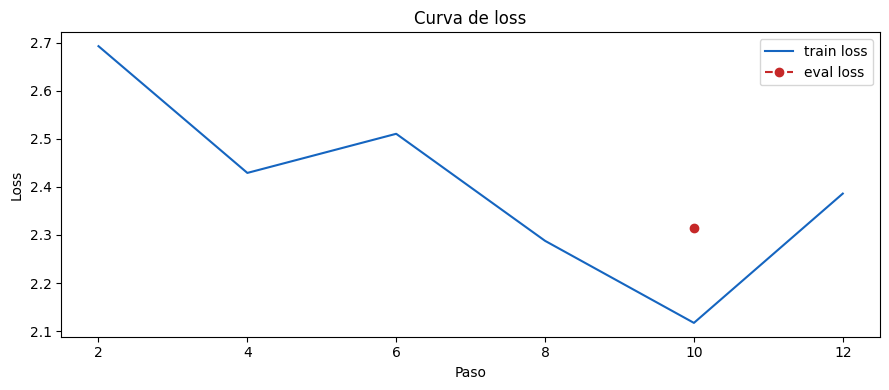

In [ ]:
# Curva de loss
log_history = trainer.state.log_history
train_logs = [(l['step'], l['loss'])      for l in log_history if 'loss'      in l]
eval_logs  = [(l['step'], l['eval_loss']) for l in log_history if 'eval_loss' in l]

if train_logs:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.plot(*zip(*train_logs), label='train loss', color='#1565C0')
    if eval_logs:
        ax.plot(*zip(*eval_logs), 'o--', label='eval loss', color='#C62828')
    ax.set_xlabel('Paso')
    ax.set_ylabel('Loss')
    ax.set_title('Curva de loss')
    ax.legend()
    plt.tight_layout()
    plt.show()

## 6 — Guardar en Drive

In [ ]:
import shutil

print(f'Guardando en {OUTPUT_DIR}...')
trainer.model.save_pretrained(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
processor.save_pretrained(OUTPUT_DIR)      # necesario para reproducir inferencia
shutil.copy(CONFIG_PATH, f'{OUTPUT_DIR}/qwen25_3b.yaml')

print('✅ Guardado')
print('   Archivos:', sorted(f.name for f in Path(OUTPUT_DIR).iterdir() if not f.is_dir()))

Guardando en /content/drive/MyDrive/contact-detection/outputs/qwen25vl_3b_baseline_100ej...
✅ Guardado
   Archivos: ['README.md', 'adapter_config.json', 'adapter_model.safetensors', 'added_tokens.json', 'chat_template.jinja', 'merges.txt', 'preprocessor_config.json', 'qwen25_3b.yaml', 'special_tokens_map.json', 'tokenizer.json', 'tokenizer_config.json', 'video_preprocessor_config.json', 'vocab.json']


## 7 — Evaluación en validación

In [ ]:
N_EVAL = min(N_VAL, len(ds['validation']))
print(f'Corriendo inferencia sobre {N_EVAL} ejemplos de val...')

results = []
for i in range(N_EVAL):
    ex       = ds['validation'][i]
    raw, parsed = predict_one(ex, model=model, processor=processor, max_new_tokens=200)
    decision    = decide(ex['item_id'], parsed)
    results.append({
        'item_id':    ex['item_id'],
        'y_true':     ex['label'],
        'y_pred':     1 if decision.is_dc else 0,
        'raw_label':  decision.raw_label,
        'confidence': decision.confidence,
        'raw_output': raw,
    })

results_df   = pd.DataFrame(results)
parse_errors = (results_df['confidence'] == 'parse_error').sum()
print(f'Parse errors: {parse_errors} / {N_EVAL} ({parse_errors/N_EVAL:.1%})')

Corriendo inferencia sobre 47 ejemplos de val...
Parse errors: 0 / 47 (0.0%)


In [ ]:
# Ver qué genera el modelo en los primeros 3 ejemplos
for i in range(min(3, len(results_df))):
    print(f"─── Ejemplo {i} ───")
    print(repr(results_df['raw_output'].iloc[i]))
    print()

─── Ejemplo 0 ───
'{"has_contact_data": 0, "source_field": ["unknown"], "reason_short": "No information about contact data or evasion signals."}'

─── Ejemplo 1 ───
'{"has_contact_data": 0, "source_field": [""], "reason_short": "No hay información sobre contacto o señales de evasión en el texto proporcionado."}'

─── Ejemplo 2 ───
'{"has_contact_data": 0, "source_field": ["Impresiones.cubic3d"], "reason_short": "No hay evidencia de contacto directo o señales de evasión en el texto proporcionado."}'



In [ ]:
def compute_metrics(y_true, y_pred, beta=2.0):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    tp = int(((y_true==1)&(y_pred==1)).sum())
    tn = int(((y_true==0)&(y_pred==0)).sum())
    fp = int(((y_true==0)&(y_pred==1)).sum())
    fn = int(((y_true==1)&(y_pred==0)).sum())
    prec = tp/(tp+fp) if (tp+fp)>0 else 0.0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0.0
    b2   = beta**2
    f2   = (1+b2)*prec*rec/(b2*prec+rec) if (b2*prec+rec)>0 else 0.0
    return dict(tp=tp, tn=tn, fp=fp, fn=fn, precision=prec, recall=rec, f2=f2)

m = compute_metrics(results_df['y_true'], results_df['y_pred'])

print('=' * 42)
print('  MÉTRICAS EN VALIDACIÓN')
print('=' * 42)
print(f'  N eval / parse errors : {N_EVAL} / {parse_errors}')
print(f'  Confusion matrix:')
print(f'              Pred 0   Pred 1')
print(f'  Real 0  :  {m["tn"]:>6}   {m["fp"]:>6}   (TN / FP)')
print(f'  Real 1  :  {m["fn"]:>6}   {m["tp"]:>6}   (FN / TP)')
print()
print(f'  Precision : {m["precision"]:.4f}')
print(f'  Recall    : {m["recall"]:.4f}')
print(f'  F2-score  : {m["f2"]:.4f}  ← métrica principal')
print('=' * 42)

  MÉTRICAS EN VALIDACIÓN
  N eval / parse errors : 47 / 0
  Confusion matrix:
              Pred 0   Pred 1
  Real 0  :      31       11   (TN / FP)
  Real 1  :       2        3   (FN / TP)

  Precision : 0.2143
  Recall    : 0.6000
  F2-score  : 0.4412  ← métrica principal


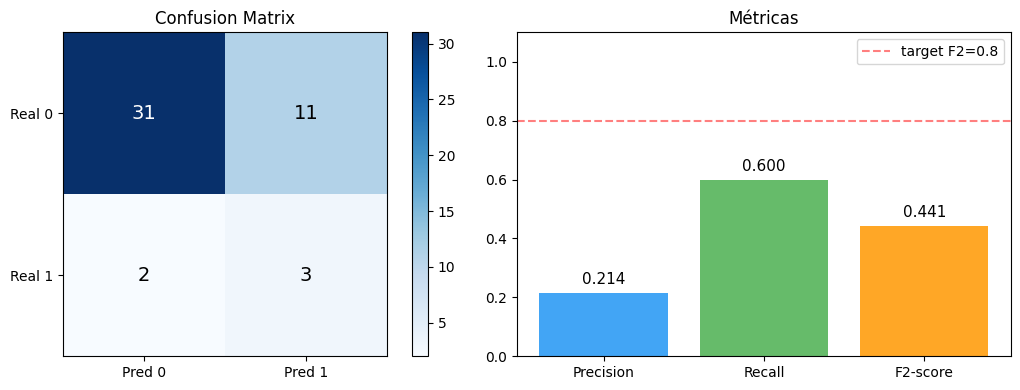

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Confusion matrix
ax = axes[0]
cm = np.array([[m['tn'], m['fp']], [m['fn'], m['tp']]])
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred 0','Pred 1'])
ax.set_yticklabels(['Real 0','Real 1'])
for (i,j), v in np.ndenumerate(cm):
    ax.text(j, i, str(v), ha='center', va='center', fontsize=14,
            color='white' if v > cm.max()/2 else 'black')
ax.set_title('Confusion Matrix')
plt.colorbar(im, ax=ax)

# Barplot de métricas
ax2 = axes[1]
vals = [m['precision'], m['recall'], m['f2']]
bars = ax2.bar(['Precision','Recall','F2-score'], vals,
               color=['#42A5F5','#66BB6A','#FFA726'])
ax2.set_ylim(0, 1.1)
ax2.set_title('Métricas')
for bar, v in zip(bars, vals):
    ax2.text(bar.get_x()+bar.get_width()/2, v+0.02, f'{v:.3f}',
             ha='center', va='bottom', fontsize=11)
ax2.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='target F2=0.8')
ax2.legend()

plt.tight_layout()
plt.show()

## 8 — Análisis de errores

In [ ]:
fp_df = results_df[(results_df['y_true']==0) & (results_df['y_pred']==1)]
fn_df = results_df[(results_df['y_true']==1) & (results_df['y_pred']==0)]

print(f'FP: {len(fp_df)}  (modelo dice DC, no es DC)')
print(f'FN: {len(fn_df)}  (modelo dice no-DC, sí es DC)  ← más crítico para F2')

print('\n--- Falsos Negativos (primeros 5) ---')
for _, row in fn_df.head(5).iterrows():
    print(f"  {row['item_id']}  conf={row['confidence']}  raw={row['raw_output'][:180]}")
    print()

FP: 11  (modelo dice DC, no es DC)
FN: 2  (modelo dice no-DC, sí es DC)  ← más crítico para F2

--- Falsos Negativos (primeros 5) ---
  1373368674  conf=high  raw={"has_contact_data": 0, "source_field": ["Edutronika"], "reason_short": "No contiene información sobre contacto directo o evasión de señales."}

  5132242788  conf=high  raw={"has_contact_data": 0, "source_field": ["Brinquedos", "Modelos de carros"], "reason_short": "A descrição não menciona nenhum contato direto ou indicações de evasão."}



In [ ]:
# Guardar resultados
results_df.to_csv(f'{OUTPUT_DIR}/eval_results.csv', index=False)
with open(f'{OUTPUT_DIR}/metrics.json', 'w') as f:
    json.dump({
        'n_train': N_TRAIN, 'n_eval': N_EVAL,
        'parse_errors': int(parse_errors),
        **{k: round(float(v), 4) for k, v in m.items()},
    }, f, indent=2)

print(f'✅ eval_results.csv y metrics.json guardados en {OUTPUT_DIR}')

✅ eval_results.csv y metrics.json guardados en /content/drive/MyDrive/contact-detection/outputs/qwen25vl_3b_baseline_100ej


---
**Siguiente paso:** analizar los FN, ajustar prompt o aumentar `N_TRAIN` para el siguiente sprint.